In [1]:
# 1. Import Libraries And Configure File Paths

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

from pgmpy.estimators import HillClimbSearch, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

warnings.filterwarnings("ignore", category=FutureWarning)

# -----------------------------------------------------------------------------
# CHANGE THIS PATH IF YOUR MIMIC-IV FILES ARE STORED ELSEWHERE.
# -----------------------------------------------------------------------------
HOSP_FOLDER = Path(r"C:\Users\Shalika\Desktop\MIMIC-IV")

# All generated outputs are saved here.
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

ANALYTIC_DATA_FILE = OUTPUT_DIR / "covid_analysis_table.csv"


def find_file(folder: Path, filename: str) -> Path:
    """Find either an uncompressed CSV or a .csv.gz MIMIC-IV table."""
    possible_paths = [
        folder / filename,
        folder / f"{filename}.gz",
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {filename} or {filename}.gz in {folder}"
    )


print("=" * 80)
print("HI823 FINAL PROJECT")
print("COVID-19 Mortality Prediction with LASSO and Bayesian Networks")
print("=" * 80)
print(f"MIMIC-IV folder: {HOSP_FOLDER}")
print(f"Output folder:   {OUTPUT_DIR.resolve()}")

HI823 FINAL PROJECT
COVID-19 Mortality Prediction with LASSO and Bayesian Networks
MIMIC-IV folder: C:\Users\Shalika\Desktop\MIMIC-IV
Output folder:   C:\Users\Shalika\outputs


C:\Users\Shalika\anaconda3\envs\bayesnet\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [3]:
# 2. Load Mimic-Iv Tables

print("\n[2] Loading MIMIC-IV patient and admission tables...")

patients = pd.read_csv(
    find_file(HOSP_FOLDER, "patients.csv"),
    usecols=[
        "subject_id",
        "gender",
        "anchor_age",
        "anchor_year",
        "anchor_year_group",
        "dod",
    ],
)

admissions = pd.read_csv(
    find_file(HOSP_FOLDER, "admissions.csv"),
    usecols=[
        "subject_id",
        "hadm_id",
        "admittime",
        "dischtime",
        "deathtime",
        "admission_type",
        "admission_location",
        "discharge_location",
        "insurance",
        "marital_status",
        "race",
        "hospital_expire_flag",
    ],
)

for column in ["admittime", "dischtime", "deathtime"]:
    admissions[column] = pd.to_datetime(admissions[column], errors="coerce")

patients["dod"] = pd.to_datetime(patients["dod"], errors="coerce")

print("Patients table shape:", patients.shape)
print("Admissions table shape:", admissions.shape)


[2] Loading MIMIC-IV patient and admission tables...
Patients table shape: (364627, 6)
Admissions table shape: (546028, 12)


In [5]:
# 3. Identify The Covid-19 Cohort

print("\n[3] Identifying COVID-19 admissions using ICD-10-CM U07.1...")

diagnoses = pd.read_csv(
    find_file(HOSP_FOLDER, "diagnoses_icd.csv"),
    dtype={
        "subject_id": "int64",
        "hadm_id": "int64",
        "seq_num": "Int64",
        "icd_code": "string",
        "icd_version": "Int64",
    },
)

diagnoses["icd_code_clean"] = (
    diagnoses["icd_code"]
    .str.upper()
    .str.replace(".", "", regex=False)
    .str.strip()
)

covid_diagnoses = diagnoses[
    (diagnoses["icd_version"] == 10)
    & (diagnoses["icd_code_clean"] == "U071")
].copy()

covid_admission_ids = set(covid_diagnoses["hadm_id"].dropna().tolist())

if len(covid_admission_ids) == 0:
    raise ValueError(
        "No admissions with ICD-10-CM U07.1 were found. "
        "Check your MIMIC-IV files and version."
    )

print("COVID-19 admissions found:", len(covid_admission_ids))

# Confirm the ICD-10 description from the dictionary.
diagnosis_dictionary = pd.read_csv(
    find_file(HOSP_FOLDER, "d_icd_diagnoses.csv"),
    dtype={"icd_code": "string", "icd_version": "Int64"},
)

diagnosis_dictionary["icd_code_clean"] = (
    diagnosis_dictionary["icd_code"]
    .str.upper()
    .str.replace(".", "", regex=False)
    .str.strip()
)

covid_description = diagnosis_dictionary[
    (diagnosis_dictionary["icd_version"] == 10)
    & (diagnosis_dictionary["icd_code_clean"] == "U071")
]

if not covid_description.empty:
    print("COVID-19 diagnosis dictionary match:")
    print(covid_description.to_string(index=False))


[3] Identifying COVID-19 admissions using ICD-10-CM U07.1...
COVID-19 admissions found: 3978
COVID-19 diagnosis dictionary match:
icd_code  icd_version long_title icd_code_clean
    U071           10   COVID-19           U071


In [6]:
# 4. Create Demographic And Hospital Variables

print("\n[4] Creating cohort demographics and hospital outcomes...")

cohort = admissions[admissions["hadm_id"].isin(covid_admission_ids)].copy()

cohort = cohort.merge(
    patients,
    on="subject_id",
    how="left",
    validate="many_to_one",
)

cohort["admission_year"] = cohort["admittime"].dt.year

cohort["age"] = (
    cohort["anchor_age"]
    + cohort["admission_year"]
    - cohort["anchor_year"]
)

cohort["hospital_los_days"] = (
    cohort["dischtime"] - cohort["admittime"]
).dt.total_seconds() / 86400

cohort["female"] = (
    cohort["gender"]
    .astype("string")
    .str.upper()
    .eq("F")
    .astype("int8")
)

cohort["in_hospital_mortality"] = (
    cohort["hospital_expire_flag"].fillna(0).astype("int8")
)

cohort["covid_diagnosis"] = 1

print("COVID cohort shape:", cohort.shape)
print("Unique patients:", cohort["subject_id"].nunique())


[4] Creating cohort demographics and hospital outcomes...
COVID cohort shape: (3978, 23)
Unique patients: 3620


In [9]:
# 5. Create Comorbidity Variables

print("\n[5] Creating ICD-10 comorbidity indicators...")

COMORBIDITY_CODES = {
    "hypertension": ["I10", "I11", "I12", "I13", "I15"],
    "diabetes": ["E08", "E09", "E10", "E11", "E13"],
    "obesity": ["E66"],
    "copd": ["J40", "J41", "J42", "J43", "J44"],
    "asthma": ["J45"],
    "chronic_kidney_disease": ["N18"],
    "heart_failure": ["I50"],
    "coronary_artery_disease": ["I20", "I21", "I22", "I23", "I24", "I25"],
    "cancer": ["C"],
    "liver_disease": ["K70", "K71", "K72", "K73", "K74", "K75", "K76"],
    "cerebrovascular_disease": [
        "I60", "I61", "I62", "I63", "I64",
        "I65", "I66", "I67", "I68", "I69",
    ],
    "dementia": ["F00", "F01", "F02", "F03", "G30"],
}

covid_diagnosis_rows = diagnoses[
    diagnoses["hadm_id"].isin(covid_admission_ids)
].copy()

for condition, prefixes in COMORBIDITY_CODES.items():
    condition_mask = covid_diagnosis_rows["icd_code_clean"].str.startswith(
        tuple(prefixes),
        na=False,
    )

    admissions_with_condition = set(
        covid_diagnosis_rows.loc[condition_mask, "hadm_id"]
    )

    cohort[condition] = (
        cohort["hadm_id"].isin(admissions_with_condition).astype("int8")
    )

comorbidity_columns = list(COMORBIDITY_CODES.keys())
cohort["comorbidity_count"] = cohort[comorbidity_columns].sum(axis=1)

print("Created comorbidity variables:")
print(comorbidity_columns)


[5] Creating ICD-10 comorbidity indicators...
Created comorbidity variables:
['hypertension', 'diabetes', 'obesity', 'copd', 'asthma', 'chronic_kidney_disease', 'heart_failure', 'coronary_artery_disease', 'cancer', 'liver_disease', 'cerebrovascular_disease', 'dementia']


In [11]:
# 6. Extract First-24-Hour Laboratory Values

print("\n[6] Identifying laboratory item IDs...")

lab_dictionary = pd.read_csv(
    find_file(HOSP_FOLDER, "d_labitems.csv"),
    dtype={"itemid": "int64"},
)

LAB_PATTERNS = {
    "wbc": r"white blood cells|\bwbc\b",
    "hemoglobin": r"\bhemoglobin\b",
    "platelets": r"platelet count|\bplatelets\b",
    "creatinine": r"\bcreatinine\b",
    "bun": r"urea nitrogen|\bbun\b",
    "glucose": r"\bglucose\b",
    "sodium": r"\bsodium\b",
    "potassium": r"\bpotassium\b",
    "bicarbonate": r"\bbicarbonate\b|total co2",
    "lactate": r"\blactate\b|lactic acid",
    "crp": r"c-reactive protein|\bcrp\b",
    "ferritin": r"\bferritin\b",
    "d_dimer": r"d-dimer|d dimer",
    "lymphocytes": r"\blymphocytes\b",
    "neutrophils": r"\bneutrophils\b",
    "alt": r"alanine aminotransferase|\balt\b",
    "ast": r"aspartate aminotransferase|\bast\b",
    "total_bilirubin": r"bilirubin, total|total bilirubin",
}

selected_lab_frames = []

for lab_name, pattern in LAB_PATTERNS.items():
    matches = lab_dictionary[
        lab_dictionary["label"]
        .astype("string")
        .str.contains(pattern, case=False, regex=True, na=False)
    ].copy()

    # Prefer blood/serum/plasma results when possible.
    if "fluid" in matches.columns:
        blood_matches = matches[
            matches["fluid"]
            .astype("string")
            .str.contains(
                "blood|serum|plasma",
                case=False,
                regex=True,
                na=False,
            )
        ]
        if not blood_matches.empty:
            matches = blood_matches

    selected = (
        matches[["itemid"]]
        .drop_duplicates()
        .assign(lab_name=lab_name)
    )
    selected_lab_frames.append(selected)

selected_lab_items = pd.concat(selected_lab_frames, ignore_index=True)
selected_lab_itemids = set(selected_lab_items["itemid"].tolist())

print("Selected laboratory item IDs:", len(selected_lab_itemids))

# Build first-24-hour windows.
lab_windows = cohort[["subject_id", "hadm_id", "admittime"]].copy()
lab_windows["window_end"] = lab_windows["admittime"] + pd.Timedelta(hours=24)

retained_lab_chunks = []
lab_columns = [
    "subject_id",
    "hadm_id",
    "itemid",
    "charttime",
    "valuenum",
    "valueuom",
]

print("Reading labevents.csv in chunks. This is the longest data-processing step...")

for chunk_number, chunk in enumerate(
    pd.read_csv(
        find_file(HOSP_FOLDER, "labevents.csv"),
        usecols=lab_columns,
        chunksize=1_000_000,
        low_memory=False,
    ),
    start=1,
):
    chunk = chunk[
        chunk["hadm_id"].isin(covid_admission_ids)
        & chunk["itemid"].isin(selected_lab_itemids)
    ].copy()

    if chunk.empty:
        continue

    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
    chunk["valuenum"] = pd.to_numeric(chunk["valuenum"], errors="coerce")
    chunk = chunk.dropna(subset=["hadm_id", "charttime", "valuenum"])

    chunk = chunk.merge(
        lab_windows,
        on=["subject_id", "hadm_id"],
        how="inner",
    )

    chunk = chunk[
        (chunk["charttime"] >= chunk["admittime"])
        & (chunk["charttime"] <= chunk["window_end"])
    ]

    chunk = chunk.merge(selected_lab_items, on="itemid", how="inner")

    retained_lab_chunks.append(
        chunk[
            [
                "subject_id",
                "hadm_id",
                "charttime",
                "itemid",
                "lab_name",
                "valuenum",
                "valueuom",
            ]
        ]
    )

    if chunk_number % 10 == 0:
        print(f"  Processed {chunk_number} chunks")

if retained_lab_chunks:
    covid_labs = pd.concat(retained_lab_chunks, ignore_index=True)
else:
    covid_labs = pd.DataFrame()

del retained_lab_chunks
gc.collect()

print("Retained first-24-hour laboratory rows:", covid_labs.shape)

if not covid_labs.empty:
    covid_labs = covid_labs.sort_values(
        ["hadm_id", "lab_name", "charttime"]
    )

    lab_summary = (
        covid_labs
        .groupby(["subject_id", "hadm_id", "lab_name"])["valuenum"]
        .agg(
            first="first",
            minimum="min",
            maximum="max",
            mean="mean",
        )
        .reset_index()
    )

    lab_summary_wide = lab_summary.pivot(
        index=["subject_id", "hadm_id"],
        columns="lab_name",
        values=["first", "minimum", "maximum", "mean"],
    )

    lab_summary_wide.columns = [
        f"first24h_{statistic}_{lab_name}"
        for statistic, lab_name in lab_summary_wide.columns
    ]

    lab_summary_wide = lab_summary_wide.reset_index()

    cohort = cohort.merge(
        lab_summary_wide,
        on=["subject_id", "hadm_id"],
        how="left",
    )


[6] Identifying laboratory item IDs...
Selected laboratory item IDs: 72
Reading labevents.csv in chunks. This is the longest data-processing step...
  Processed 10 chunks
  Processed 20 chunks
  Processed 30 chunks
  Processed 40 chunks
  Processed 50 chunks
  Processed 60 chunks
  Processed 70 chunks
  Processed 80 chunks
  Processed 90 chunks
  Processed 100 chunks
  Processed 110 chunks
  Processed 120 chunks
  Processed 130 chunks
  Processed 140 chunks
  Processed 150 chunks
Retained first-24-hour laboratory rows: (66360, 7)


In [12]:
# 7. Build The Final Analytical Dataset

print("\n[7] Building the final admission-level analytical dataset...")

base_columns = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "admission_year",
    "age",
    "gender",
    "female",
    "race",
    "insurance",
    "marital_status",
    "admission_type",
    "admission_location",
    "discharge_location",
    "covid_diagnosis",
    "hospital_los_days",
    "in_hospital_mortality",
    "comorbidity_count",
]

lab_columns_final = [
    column for column in cohort.columns if column.startswith("first24h_")
]

final_columns = list(
    dict.fromkeys(
        column
        for column in (base_columns + comorbidity_columns + lab_columns_final)
        if column in cohort.columns
    )
)

covid_table = cohort[final_columns].copy()

covid_table = (
    covid_table
    .drop_duplicates(subset=["subject_id", "hadm_id"])
    .sort_values(["subject_id", "admittime"])
    .reset_index(drop=True)
)

print("Final table shape:", covid_table.shape)
print("Unique patients:", covid_table["subject_id"].nunique())
print("Unique admissions:", covid_table["hadm_id"].nunique())

covid_table.to_csv(ANALYTIC_DATA_FILE, index=False)
print("Saved analytical table to:", ANALYTIC_DATA_FILE)


[7] Building the final admission-level analytical dataset...
Final table shape: (3978, 102)
Unique patients: 3620
Unique admissions: 3978
Saved analytical table to: outputs\covid_analysis_table.csv


In [15]:
# 8. Descriptive Statistics

print("\n[8] Generating descriptive statistics...")

binary_vars = [
    "female",
    "hypertension",
    "diabetes",
    "obesity",
    "copd",
    "asthma",
    "chronic_kidney_disease",
    "heart_failure",
    "coronary_artery_disease",
    "cancer",
    "liver_disease",
    "cerebrovascular_disease",
    "dementia",
    "in_hospital_mortality",
]

binary_summary = []
for variable in binary_vars:
    if variable in covid_table.columns:
        n = covid_table[variable].sum()
        percent = covid_table[variable].mean() * 100
        binary_summary.append(
            {
                "Characteristic": variable,
                "n": int(n),
                "Percent": round(percent, 1),
            }
        )

binary_summary = pd.DataFrame(binary_summary)

continuous_vars = [
    "age",
    "hospital_los_days",
    "comorbidity_count",
    "first24h_first_wbc",
    "first24h_first_creatinine",
    "first24h_first_glucose",
    "first24h_first_potassium",
    "first24h_first_sodium",
    "first24h_first_platelets",
    "first24h_first_hemoglobin",
]

continuous_summary = []
for variable in continuous_vars:
    if variable in covid_table.columns:
        series = covid_table[variable].dropna()
        continuous_summary.append(
            {
                "Characteristic": variable,
                "N_nonmissing": int(series.shape[0]),
                "Mean": round(series.mean(), 2),
                "SD": round(series.std(), 2),
                "Median": round(series.median(), 2),
                "Q1": round(series.quantile(0.25), 2),
                "Q3": round(series.quantile(0.75), 2),
            }
        )

continuous_summary = pd.DataFrame(continuous_summary)

binary_summary.to_csv(TABLE_DIR / "Table1_Binary_Characteristics.csv", index=False)
continuous_summary.to_csv(TABLE_DIR / "Table1_Continuous_Characteristics.csv", index=False)

print("\nBinary characteristics:")
print(binary_summary.to_string(index=False))
print("\nContinuous characteristics:")
print(continuous_summary.to_string(index=False))


[8] Generating descriptive statistics...

Binary characteristics:
         Characteristic    n  Percent
                 female 1921     48.3
           hypertension 2338     58.8
               diabetes 1357     34.1
                obesity  669     16.8
                   copd  403     10.1
                 asthma  427     10.7
 chronic_kidney_disease  946     23.8
          heart_failure  740     18.6
coronary_artery_disease  863     21.7
                 cancer  461     11.6
          liver_disease  465     11.7
cerebrovascular_disease  320      8.0
               dementia  348      8.7
  in_hospital_mortality  412     10.4

Continuous characteristics:
           Characteristic  N_nonmissing   Mean    SD  Median     Q1    Q3
                      age          3978  63.50 18.08   65.00  52.00  77.0
        hospital_los_days          3978  10.79 15.06    6.02   2.81  12.5
        comorbidity_count          3978   2.35  1.75    2.00   1.00   4.0
       first24h_first_wbc          323

In [17]:
# 9. Data Preprocessing For Lasso

print("\n[9] Preparing predictors for LASSO logistic regression...")

outcome = "in_hospital_mortality"

candidate_predictors = [
    "age",
    "female",
    "hypertension",
    "diabetes",
    "obesity",
    "copd",
    "asthma",
    "chronic_kidney_disease",
    "heart_failure",
    "coronary_artery_disease",
    "cancer",
    "liver_disease",
    "cerebrovascular_disease",
    "dementia",
    "comorbidity_count",
    "first24h_first_wbc",
    "first24h_first_creatinine",
    "first24h_first_glucose",
    "first24h_first_sodium",
    "first24h_first_potassium",
    "first24h_first_lactate",
    "first24h_first_crp",
    "first24h_first_ferritin",
    "first24h_first_d_dimer",
    "first24h_first_platelets",
    "first24h_first_hemoglobin",
]

candidate_predictors = [
    column for column in candidate_predictors if column in covid_table.columns
]

model_df = covid_table[candidate_predictors + [outcome]].copy()

# Remove predictors with >50% missingness.
missing_percent = model_df.isna().mean() * 100
missing_summary = (
    missing_percent
    .rename("Missing_Percent")
    .reset_index()
    .rename(columns={"index": "Variable"})
    .sort_values("Missing_Percent", ascending=False)
)
missing_summary.to_csv(TABLE_DIR / "Missing_Data_Summary.csv", index=False)

columns_to_remove = missing_percent[missing_percent > 50].index.tolist()
# Never remove the outcome because of this predictor-screening rule.
columns_to_remove = [c for c in columns_to_remove if c != outcome]

print("Removed because of >50% missingness:")
print(columns_to_remove)

model_df = model_df.drop(columns=columns_to_remove)
candidate_predictors = [
    column for column in candidate_predictors if column in model_df.columns
]

# Remove predictors with no variation.
constant_columns = [
    column
    for column in candidate_predictors
    if model_df[column].nunique(dropna=True) <= 1
]

print("Removed because of no variation:")
print(constant_columns)

model_df = model_df.drop(columns=constant_columns)
candidate_predictors = [
    column for column in candidate_predictors if column not in constant_columns
]

# Median imputation.
X = model_df[candidate_predictors]
y = model_df[outcome].astype(int)

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index,
)

print("Modeling matrix shape:", X_imputed.shape)
print("Outcome counts:")
print(y.value_counts().sort_index())


[9] Preparing predictors for LASSO logistic regression...
Removed because of >50% missingness:
['first24h_first_crp', 'first24h_first_ferritin', 'first24h_first_d_dimer']
Removed because of no variation:
[]
Modeling matrix shape: (3978, 23)
Outcome counts:
in_hospital_mortality
0    3566
1     412
Name: count, dtype: int64


In [19]:
# 10. Lasso Logistic Regression

print("\n[10] Fitting LASSO logistic regression with 5-fold cross-validation...")

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

lasso_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "lasso",
            LogisticRegressionCV(
                Cs=20,
                cv=cv,
                penalty="l1",
                solver="saga",
                scoring="roc_auc",
                max_iter=10000,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

lasso_pipeline.fit(X_imputed, y)

lasso_model = lasso_pipeline.named_steps["lasso"]
coefficients = pd.Series(
    lasso_model.coef_[0],
    index=X_imputed.columns,
    name="coefficient",
)

selected_variables = coefficients[coefficients != 0].sort_values(
    key=np.abs,
    ascending=False,
)

lasso_results = (
    selected_variables
    .reset_index()
    .rename(columns={"index": "variable"})
)

# Because continuous predictors are standardized, this exponentiated coefficient
# corresponds to a one-standard-deviation change for those predictors.
lasso_results["exp_coefficient"] = np.exp(lasso_results["coefficient"])
lasso_results.to_csv(TABLE_DIR / "Table2_LASSO_Selected_Predictors.csv", index=False)

print("Variables selected by LASSO:")
print(lasso_results.to_string(index=False))


[10] Fitting LASSO logistic regression with 5-fold cross-validation...
Variables selected by LASSO:
                 variable  coefficient  exp_coefficient
                      age     0.534997         1.707444
       first24h_first_wbc     0.330350         1.391455
            liver_disease     0.255237         1.290768
 first24h_first_potassium     0.217791         1.243328
   first24h_first_glucose     0.197070         1.217829
 first24h_first_platelets    -0.184086         0.831865
first24h_first_creatinine     0.148963         1.160630
                 diabetes    -0.145565         0.864534
  cerebrovascular_disease     0.143419         1.154213
                   asthma    -0.137766         0.871303
                   female    -0.125012         0.882487
        comorbidity_count     0.116768         1.123859
                     copd     0.105815         1.111616
                  obesity     0.105537         1.111307
             hypertension    -0.098256         0.906417
fir

In [21]:
# 11. Model Evaluation: Roc Auc, Confusion Matrix, And Threshold Analysis

print("\n[11] Evaluating LASSO model performance...")

predicted_probability = cross_val_predict(
    lasso_pipeline,
    X_imputed,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

predicted_class = (predicted_probability >= 0.5).astype(int)

auc = roc_auc_score(y, predicted_probability)
cm = confusion_matrix(y, predicted_class)
report = classification_report(y, predicted_class, output_dict=True)

print("Cross-validated ROC AUC:", round(auc, 3))
print("\nConfusion matrix at threshold 0.50:")
print(cm)
print("\nClassification report at threshold 0.50:")
print(classification_report(y, predicted_class))

# Save classification report.
pd.DataFrame(report).transpose().to_csv(
    TABLE_DIR / "LASSO_Classification_Report.csv"
)

# ROC curve and Youden's Index.
fpr, tpr, thresholds = roc_curve(y, predicted_probability)
youden_index = tpr - fpr
best_index = np.argmax(youden_index)
best_threshold = thresholds[best_index]
best_sensitivity = tpr[best_index]
best_specificity = 1 - fpr[best_index]

threshold_results = pd.DataFrame(
    {
        "Metric": ["ROC_AUC", "Best_Threshold", "Sensitivity", "Specificity"],
        "Value": [auc, best_threshold, best_sensitivity, best_specificity],
    }
)
threshold_results.to_csv(TABLE_DIR / "LASSO_Performance_Summary.csv", index=False)

print("\nYouden's Index threshold analysis:")
print("Best threshold:", round(best_threshold, 3))
print("Sensitivity:", round(best_sensitivity, 3))
print("Specificity:", round(best_specificity, 3))


[11] Evaluating LASSO model performance...
Cross-validated ROC AUC: 0.764

Confusion matrix at threshold 0.50:
[[3542   24]
 [ 397   15]]

Classification report at threshold 0.50:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      3566
           1       0.38      0.04      0.07       412

    accuracy                           0.89      3978
   macro avg       0.64      0.51      0.51      3978
weighted avg       0.85      0.89      0.85      3978


Youden's Index threshold analysis:
Best threshold: 0.073
Sensitivity: 0.857
Specificity: 0.541



[12] Creating ROC curve...


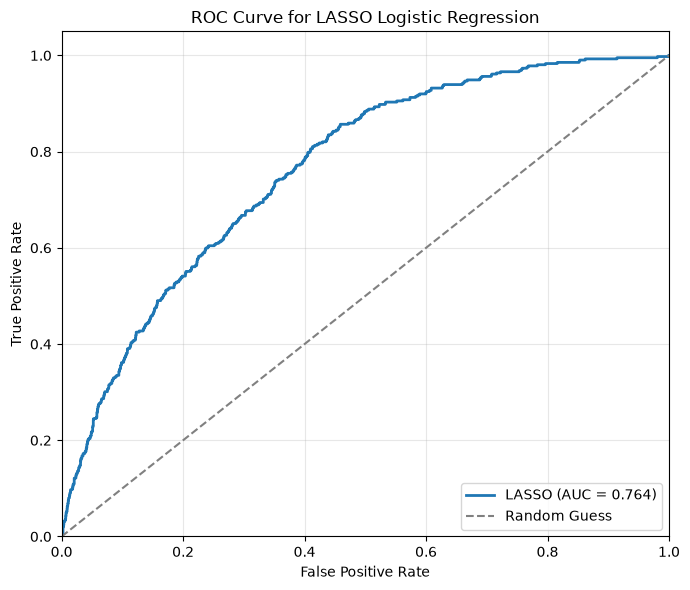

In [23]:
# 12. Roc Curve

print("\n[12] Creating ROC curve...")

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"LASSO (AUC = {auc:.3f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Guess",
)
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for LASSO Logistic Regression")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "ROC_Curve_LASSO.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

[13] Creating LASSO coefficient plot...


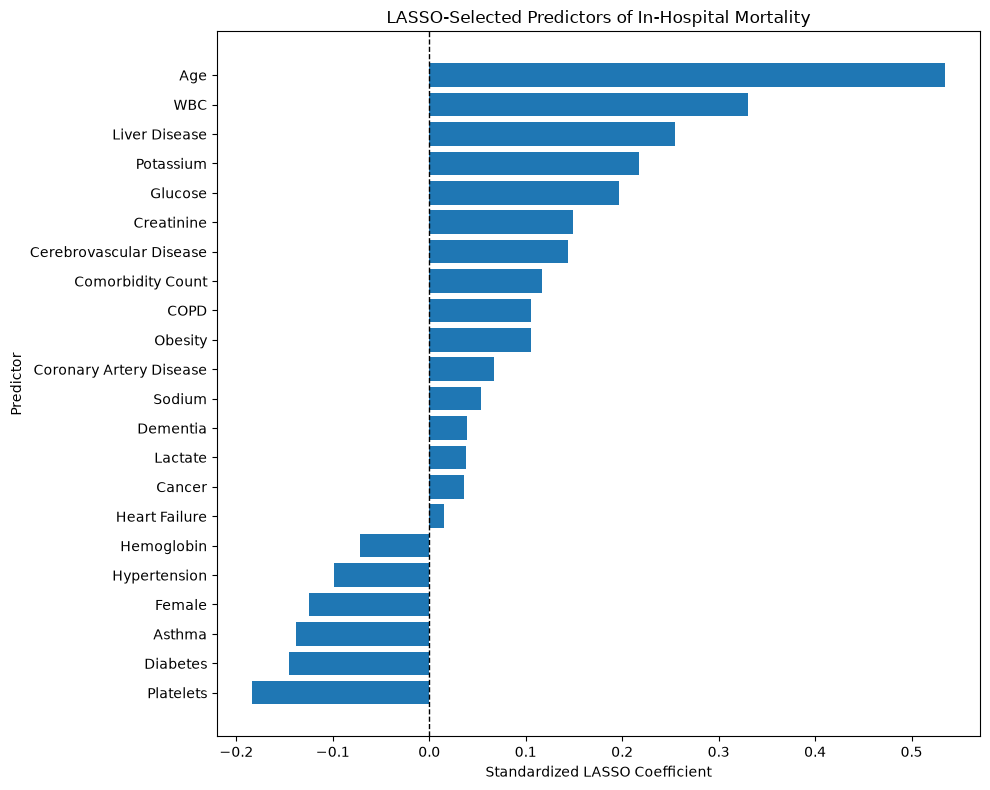

In [25]:
# 13. Lasso Coefficient Visualization

print("[13] Creating LASSO coefficient plot...")

pretty_names = {
    "age": "Age",
    "female": "Female",
    "hypertension": "Hypertension",
    "diabetes": "Diabetes",
    "obesity": "Obesity",
    "copd": "COPD",
    "asthma": "Asthma",
    "chronic_kidney_disease": "Chronic Kidney Disease",
    "heart_failure": "Heart Failure",
    "coronary_artery_disease": "Coronary Artery Disease",
    "cancer": "Cancer",
    "liver_disease": "Liver Disease",
    "cerebrovascular_disease": "Cerebrovascular Disease",
    "dementia": "Dementia",
    "comorbidity_count": "Comorbidity Count",
    "first24h_first_wbc": "WBC",
    "first24h_first_creatinine": "Creatinine",
    "first24h_first_glucose": "Glucose",
    "first24h_first_sodium": "Sodium",
    "first24h_first_potassium": "Potassium",
    "first24h_first_lactate": "Lactate",
    "first24h_first_crp": "C-Reactive Protein",
    "first24h_first_ferritin": "Ferritin",
    "first24h_first_d_dimer": "D-Dimer",
    "first24h_first_platelets": "Platelets",
    "first24h_first_hemoglobin": "Hemoglobin",
}

plot_data = selected_variables.sort_values()
plot_labels = [pretty_names.get(variable, variable) for variable in plot_data.index]

plt.figure(figsize=(10, 8))
plt.barh(plot_labels, plot_data.values)
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Standardized LASSO Coefficient")
plt.ylabel("Predictor")
plt.title("LASSO-Selected Predictors of In-Hospital Mortality")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "LASSO_Coefficient_Plot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [27]:
# 14. Prepare Data For Bayesian Network Analysis

print("\n[14] Preparing LASSO-selected variables for Bayesian network analysis...")

selected_predictors = selected_variables.index.tolist()
bn_df = model_df[selected_predictors + [outcome]].copy()

binary_variables = {
    "female",
    "hypertension",
    "diabetes",
    "obesity",
    "copd",
    "asthma",
    "chronic_kidney_disease",
    "heart_failure",
    "coronary_artery_disease",
    "cancer",
    "liver_disease",
    "cerebrovascular_disease",
    "dementia",
    outcome,
}


def discretize_three_levels(series: pd.Series) -> pd.Series:
    """Robustly discretize a numeric series into low/medium/high categories."""
    numeric = pd.to_numeric(series, errors="coerce")
    numeric = numeric.fillna(numeric.median())

    # If fewer than three unique values remain, keep values as strings.
    if numeric.nunique() < 3:
        return numeric.astype(str)

    # qcut without labels first avoids label-count errors when duplicate bins drop.
    cats = pd.qcut(numeric, q=3, duplicates="drop")
    codes = cats.cat.codes
    n_bins = int(codes.max()) + 1

    if n_bins == 3:
        mapping = {0: "low", 1: "medium", 2: "high"}
    elif n_bins == 2:
        mapping = {0: "low", 1: "high"}
    else:
        return numeric.astype(str)

    return codes.map(mapping).astype(str)


for column in bn_df.columns:
    if column in binary_variables:
        bn_df[column] = (
            bn_df[column]
            .fillna(0)
            .astype(int)
            .astype(str)
        )
    else:
        bn_df[column] = discretize_three_levels(bn_df[column])

print("Bayesian network data shape:", bn_df.shape)


[14] Preparing LASSO-selected variables for Bayesian network analysis...
Bayesian network data shape: (3978, 23)


In [29]:
# 15. Bayesian Network Structure Learning

print("\n[15] Learning Bayesian network structure with Hill-Climbing + BIC...")

try:
    from pgmpy.estimators import BIC
    scoring_method = BIC(bn_df)
except ImportError:
    from pgmpy.estimators import BicScore
    scoring_method = BicScore(bn_df)

search = HillClimbSearch(bn_df)
learned_model = search.estimate(
    scoring_method=scoring_method,
    max_indegree=4,
    show_progress=True,
)

learned_edges = list(learned_model.edges())
print("Learned edges:")
for edge in learned_edges:
    print(edge)

pd.DataFrame(learned_edges, columns=["From", "To"]).to_csv(
    TABLE_DIR / "Bayesian_Network_Edges.csv",
    index=False,
)


[15] Learning Bayesian network structure with Hill-Climbing + BIC...


  0%|          | 0/1000000 [00:00<?, ?it/s]

Learned edges:
('age', 'dementia')
('age', 'obesity')
('age', 'in_hospital_mortality')
('first24h_first_wbc', 'first24h_first_hemoglobin')
('first24h_first_wbc', 'first24h_first_lactate')
('first24h_first_potassium', 'first24h_first_creatinine')
('first24h_first_potassium', 'first24h_first_glucose')
('first24h_first_glucose', 'first24h_first_platelets')
('first24h_first_glucose', 'first24h_first_creatinine')
('first24h_first_glucose', 'diabetes')
('first24h_first_glucose', 'first24h_first_lactate')
('first24h_first_glucose', 'comorbidity_count')
('first24h_first_glucose', 'first24h_first_wbc')
('first24h_first_platelets', 'first24h_first_wbc')
('first24h_first_platelets', 'first24h_first_hemoglobin')
('first24h_first_creatinine', 'first24h_first_platelets')
('first24h_first_creatinine', 'comorbidity_count')
('first24h_first_creatinine', 'first24h_first_hemoglobin')
('first24h_first_creatinine', 'first24h_first_wbc')
('first24h_first_creatinine', 'female')
('first24h_first_creatinine', 

In [31]:
# 16. Markov Blanket Analysis

print("\n[16] Identifying the Markov blanket of in-hospital mortality...")

target = outcome
parents = set(learned_model.predecessors(target))
children = set(learned_model.successors(target))
spouses = set()

for child in children:
    child_parents = set(learned_model.predecessors(child))
    spouses.update(child_parents - {target})

markov_blanket = parents | children | spouses

print("Parents:", sorted(parents))
print("Children:", sorted(children))
print("Spouses:", sorted(spouses))
print("Markov blanket:", sorted(markov_blanket))

markov_blanket_table = pd.DataFrame(
    {
        "Relationship": ["Parents", "Children", "Spouses", "Complete Markov Blanket"],
        "Variables": [
            "; ".join(sorted(parents)) if parents else "None",
            "; ".join(sorted(children)) if children else "None",
            "; ".join(sorted(spouses)) if spouses else "None",
            "; ".join(sorted(markov_blanket)) if markov_blanket else "None",
        ],
    }
)
markov_blanket_table.to_csv(TABLE_DIR / "Table3_Markov_Blanket.csv", index=False)


[16] Identifying the Markov blanket of in-hospital mortality...
Parents: ['age', 'first24h_first_creatinine']
Children: []
Spouses: []
Markov blanket: ['age', 'first24h_first_creatinine']


In [55]:
# 17. Bayesian Parameter Learning

print("\n[17] Estimating Bayesian network conditional probability tables...")

bayesian_network = DiscreteBayesianNetwork(learned_model.edges())
bayesian_network.add_nodes_from(learned_model.nodes())

estimator = BayesianEstimator(bayesian_network, bn_df)
cpds = estimator.get_parameters(
    prior_type="BDeu",
    equivalent_sample_size=10,
)
bayesian_network.add_cpds(*cpds)

print("Model valid:", bayesian_network.check_model())


[17] Estimating Bayesian network conditional probability tables...
Model valid: True


In [35]:
# 18. Bayesian Inference

print("\n[18] Performing Bayesian probability inference...")

inference = VariableElimination(bayesian_network)

mortality_probability = inference.query(variables=[outcome])
print("Overall mortality probability:")
print(mortality_probability)

# Example patient evidence based on nodes present in the learned network.
evidence = {}
if "age" in bayesian_network.nodes():
    evidence["age"] = "high"
if "first24h_first_creatinine" in bayesian_network.nodes():
    evidence["first24h_first_creatinine"] = "high"

if evidence:
    patient_probability = inference.query(
        variables=[outcome],
        evidence=evidence,
    )
    print("\nExample evidence:")
    print(evidence)
    print("Predicted mortality probability:")
    print(patient_probability)
else:
    patient_probability = None
    print("No example evidence variables were available in the learned network.")

# Save simple probability results when state '1' exists.
def probability_of_state_one(factor):
    """Return P(variable='1') from a pgmpy DiscreteFactor if available."""
    state_names = factor.state_names.get(factor.variables[0], [])
    if "1" in state_names:
        return float(factor.values[state_names.index("1")])
    return np.nan

baseline_mortality = probability_of_state_one(mortality_probability)
conditional_mortality = (
    probability_of_state_one(patient_probability)
    if patient_probability is not None
    else np.nan
)

inference_results = pd.DataFrame(
    {
        "Scenario": [
            "Overall population",
            "High age + high first-24-hour creatinine",
        ],
        "Mortality_Probability": [baseline_mortality, conditional_mortality],
    }
)
inference_results.to_csv(TABLE_DIR / "Table4_Bayesian_Inference.csv", index=False)


[18] Performing Bayesian probability inference...
Overall mortality probability:
+--------------------------+------------------------------+
| in_hospital_mortality    |   phi(in_hospital_mortality) |
+==========================+==============================+
| in_hospital_mortality(0) |                       0.8962 |
+--------------------------+------------------------------+
| in_hospital_mortality(1) |                       0.1038 |
+--------------------------+------------------------------+

Example evidence:
{'age': 'high', 'first24h_first_creatinine': 'high'}
Predicted mortality probability:
+--------------------------+------------------------------+
| in_hospital_mortality    |   phi(in_hospital_mortality) |
+==========================+==============================+
| in_hospital_mortality(0) |                       0.8001 |
+--------------------------+------------------------------+
| in_hospital_mortality(1) |                       0.1999 |
+--------------------------+-----


[19] Creating Bayesian network visualizations...


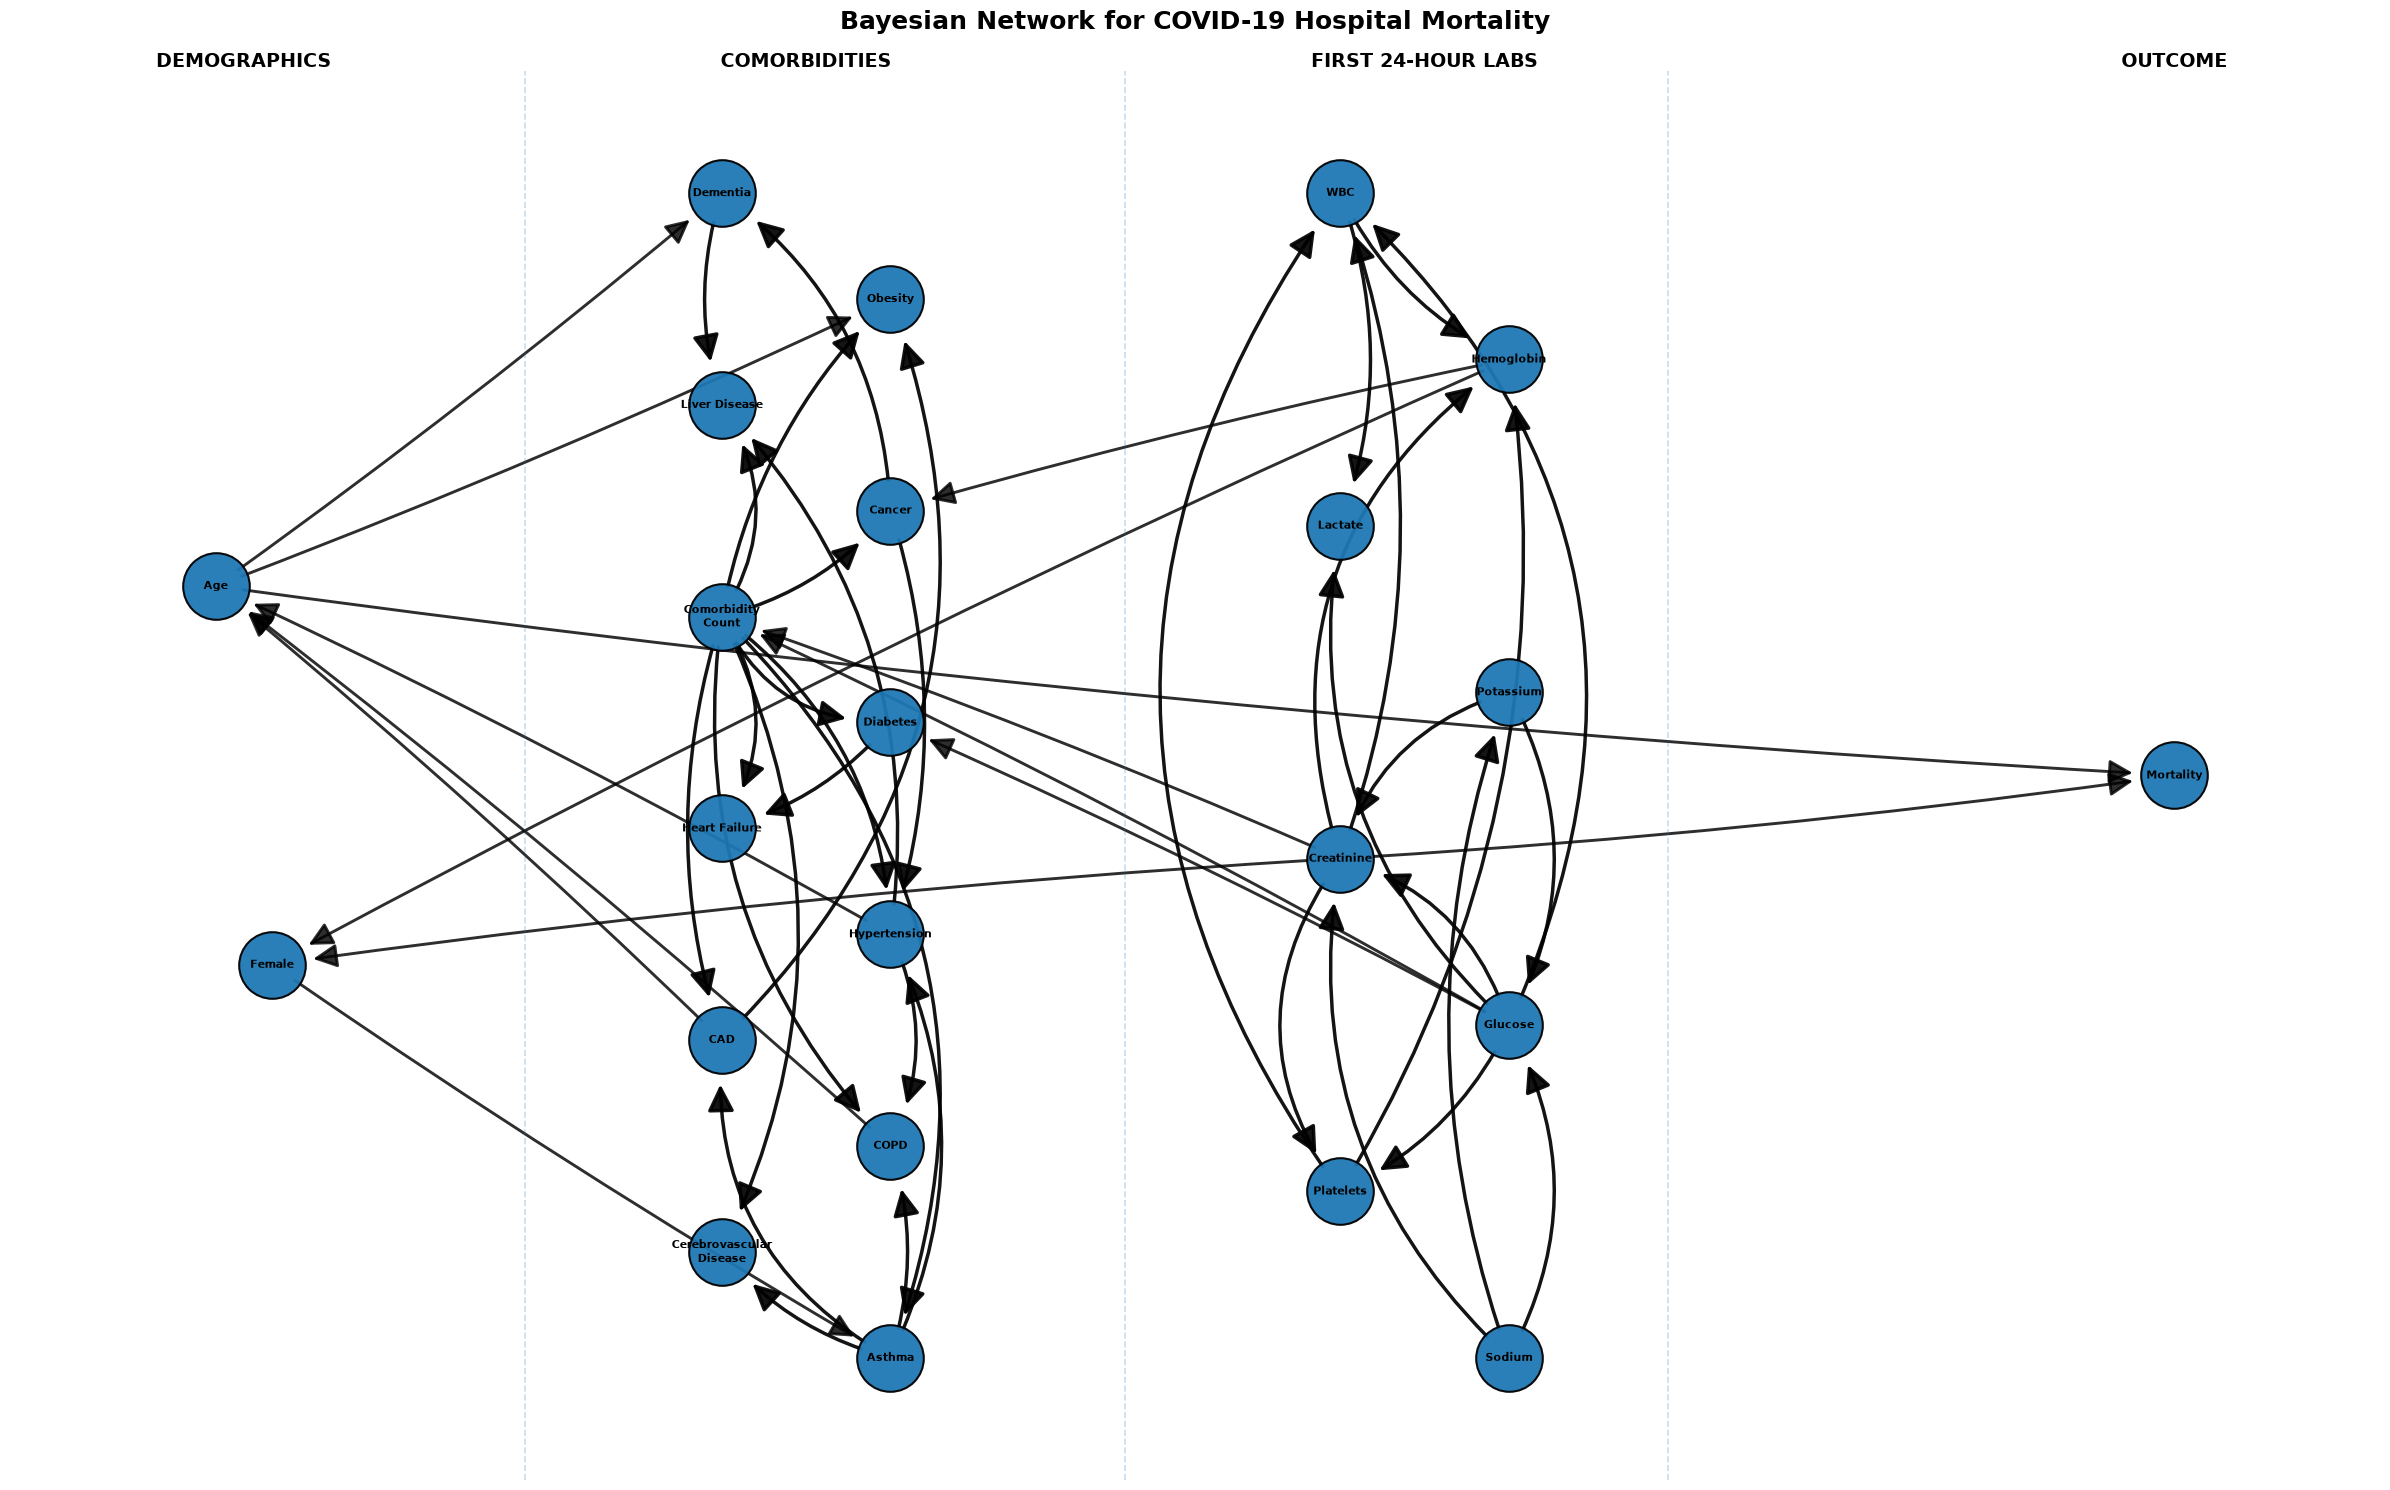

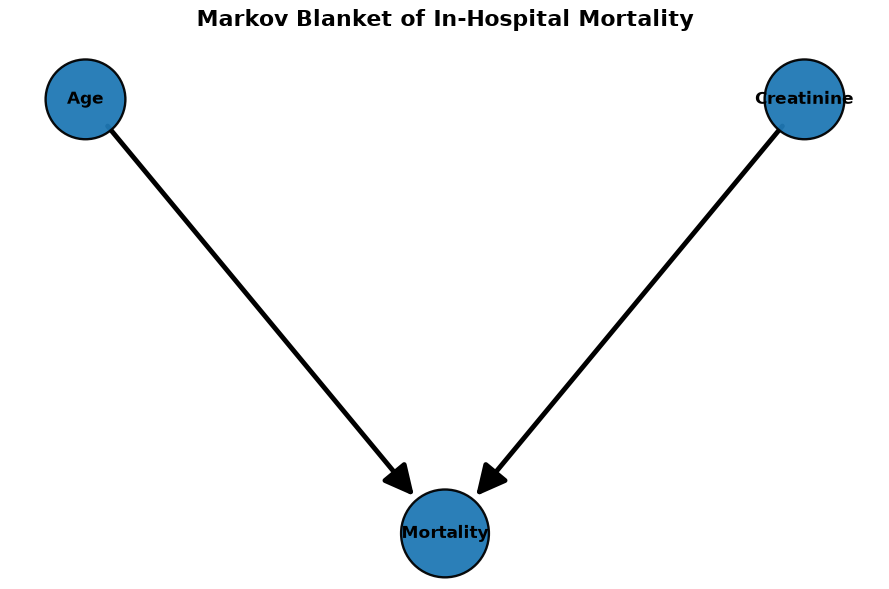


Markov Blanket Summary

Parents of Mortality:
  - Age
  - Creatinine

Children of Mortality:
  None

Spouses of Mortality:
  None

Complete Markov Blanket:
  - Age
  - Creatinine

Bayesian network and Markov blanket visualizations created successfully.


In [51]:
# 19. Bayesian Network and Markov Blanket Visualizations

print("\n[19] Creating Bayesian network visualizations...")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ============================================================
# A. FULL BAYESIAN NETWORK
# ============================================================

# Create directed graph
graph = nx.DiGraph(
    bayesian_network.edges()
)

graph.add_nodes_from(
    bayesian_network.nodes()
)

# ============================================================
# CLEAN DISPLAY LABELS
# ============================================================

pretty_network_labels = {

    # Outcome
    "in_hospital_mortality": "Mortality",

    # Demographics
    "age": "Age",
    "female": "Female",

    # Comorbidities
    "hypertension": "Hypertension",
    "diabetes": "Diabetes",
    "obesity": "Obesity",
    "copd": "COPD",
    "asthma": "Asthma",
    "chronic_kidney_disease": "CKD",
    "heart_failure": "Heart Failure",
    "coronary_artery_disease": "CAD",
    "cancer": "Cancer",
    "liver_disease": "Liver Disease",
    "cerebrovascular_disease": "Cerebrovascular\nDisease",
    "dementia": "Dementia",
    "comorbidity_count": "Comorbidity\nCount",

    # First 24-hour laboratory values
    "first24h_first_creatinine": "Creatinine",
    "first24h_first_wbc": "WBC",
    "first24h_first_glucose": "Glucose",
    "first24h_first_potassium": "Potassium",
    "first24h_first_sodium": "Sodium",
    "first24h_first_platelets": "Platelets",
    "first24h_first_hemoglobin": "Hemoglobin",
    "first24h_first_lactate": "Lactate",
    "first24h_first_bun": "BUN",
    "first24h_first_bicarbonate": "Bicarbonate",
    "first24h_first_lymphocytes": "Lymphocytes",
    "first24h_first_neutrophils": "Neutrophils",
    "first24h_first_alt": "ALT",
    "first24h_first_ast": "AST",
    "first24h_first_bilirubin": "Bilirubin",
}

network_labels = {
    node: pretty_network_labels.get(
        node,
        node.replace("_", " ").title()
    )
    for node in graph.nodes()
}

# ============================================================
# DEFINE CLINICAL SECTIONS
# ============================================================

demographics = [
    node
    for node in graph.nodes()
    if node in [
        "age",
        "female"
    ]
]

comorbidities = [
    node
    for node in graph.nodes()
    if node in [
        "hypertension",
        "diabetes",
        "obesity",
        "copd",
        "asthma",
        "chronic_kidney_disease",
        "heart_failure",
        "coronary_artery_disease",
        "cancer",
        "liver_disease",
        "cerebrovascular_disease",
        "dementia",
        "comorbidity_count"
    ]
]

labs = [
    node
    for node in graph.nodes()
    if node.startswith("first24h_")
]

outcomes = [
    node
    for node in graph.nodes()
    if node == outcome
]

# Capture any variables that do not belong to the categories above
assigned_nodes = set(
    demographics +
    comorbidities +
    labs +
    outcomes
)

other_nodes = [
    node
    for node in graph.nodes()
    if node not in assigned_nodes
]

# ============================================================
# STAGGERED NODE POSITION FUNCTION
# ============================================================
# Instead of placing every variable on exactly the same
# vertical line, nodes alternate slightly left and right.
# This gives arrows more room and prevents multiple edges from
# being drawn directly on top of each other.
# ============================================================

def staggered_vertical_positions(
    nodes,
    center_x,
    y_top,
    y_bottom,
    stagger=0.35
):

    if len(nodes) == 0:
        return {}

    if len(nodes) == 1:
        return {
            nodes[0]: (
                center_x,
                (y_top + y_bottom) / 2
            )
        }

    ys = np.linspace(
        y_top,
        y_bottom,
        len(nodes)
    )

    node_positions = {}

    for i, (node, y) in enumerate(
        zip(nodes, ys)
    ):

        # Alternate nodes left and right
        if i % 2 == 0:
            x = center_x - stagger
        else:
            x = center_x + stagger

        node_positions[node] = (
            x,
            y
        )

    return node_positions

# ============================================================
# CREATE LAYERED + STAGGERED POSITIONS
# ============================================================

positions = {}

# ------------------------------------------------------------
# Demographics
# ------------------------------------------------------------

positions.update(
    staggered_vertical_positions(
        demographics,
        center_x=0,
        y_top=1.3,
        y_bottom=-1.3,
        stagger=0.15
    )
)

# ------------------------------------------------------------
# Comorbidities
# ------------------------------------------------------------

positions.update(
    staggered_vertical_positions(
        comorbidities,
        center_x=3.0,
        y_top=4.0,
        y_bottom=-4.0,
        stagger=0.45
    )
)

# ------------------------------------------------------------
# First 24-hour labs
# ------------------------------------------------------------

positions.update(
    staggered_vertical_positions(
        labs,
        center_x=6.3,
        y_top=4.0,
        y_bottom=-4.0,
        stagger=0.45
    )
)

# ------------------------------------------------------------
# Other variables, if present
# ------------------------------------------------------------

positions.update(
    staggered_vertical_positions(
        other_nodes,
        center_x=8.5,
        y_top=2.5,
        y_bottom=-2.5,
        stagger=0.30
    )
)

# ------------------------------------------------------------
# Outcome
# ------------------------------------------------------------

positions.update(
    staggered_vertical_positions(
        outcomes,
        center_x=10.3,
        y_top=0,
        y_bottom=0,
        stagger=0
    )
)

# ============================================================
# DIVIDE EDGES INTO TYPES
# ============================================================
# Within-comorbidity and within-lab edges are drawn separately
# so that they can receive different curvature.
# ============================================================

comorbidity_set = set(
    comorbidities
)

lab_set = set(
    labs
)

within_comorbidity_edges = []

within_lab_edges = []

other_edges = []

for source, target in graph.edges():

    # Both variables are comorbidities
    if (
        source in comorbidity_set
        and target in comorbidity_set
    ):

        within_comorbidity_edges.append(
            (source, target)
        )

    # Both variables are laboratory measurements
    elif (
        source in lab_set
        and target in lab_set
    ):

        within_lab_edges.append(
            (source, target)
        )

    # Cross-section edge
    else:

        other_edges.append(
            (source, target)
        )

# ============================================================
# DRAW FULL BAYESIAN NETWORK
# ============================================================

plt.figure(
    figsize=(24, 15)
)

# ------------------------------------------------------------
# Draw nodes
# ------------------------------------------------------------

nx.draw_networkx_nodes(
    graph,
    pos=positions,
    node_size=2300,
    edgecolors="black",
    linewidths=1.5,
    alpha=0.95
)

nx.draw_networkx_edges(
    graph,
    pos=positions,
    edgelist=other_edges,
    arrows=True,
    arrowsize=36,
    width=2.1,
    arrowstyle="-|>",
    edge_color="black",
    alpha=0.82,
    connectionstyle="arc3,rad=0.02",
    min_source_margin=20,
    min_target_margin=30
)

for i, edge in enumerate(
    within_comorbidity_edges
):

    # Cycle through different curvature amounts
    curve_options = [
        0.16,
        -0.16,
        0.24,
        -0.24,
        0.32,
        -0.32
    ]

    curve = curve_options[
        i % len(curve_options)
    ]

    nx.draw_networkx_edges(
        graph,
        pos=positions,
        edgelist=[edge],
        arrows=True,
        arrowsize=40,
        width=2.5,
        arrowstyle="-|>",
        edge_color="black",
        alpha=0.92,
        connectionstyle=f"arc3,rad={curve}",
        min_source_margin=22,
        min_target_margin=32
    )

for i, edge in enumerate(
    within_lab_edges
):

    curve_options = [
        0.18,
        -0.18,
        0.27,
        -0.27,
        0.36,
        -0.36
    ]

    curve = curve_options[
        i % len(curve_options)
    ]

    nx.draw_networkx_edges(
        graph,
        pos=positions,
        edgelist=[edge],
        arrows=True,
        arrowsize=40,
        width=2.5,
        arrowstyle="-|>",
        edge_color="black",
        alpha=0.92,
        connectionstyle=f"arc3,rad={curve}",
        min_source_margin=22,
        min_target_margin=32
    )

# ============================================================
# NODE LABELS
# ============================================================

nx.draw_networkx_labels(
    graph,
    pos=positions,
    labels=network_labels,
    font_size=8,
    font_weight="bold"
)

# ============================================================
# SECTION LABELS
# ============================================================

section_y = 4.9


plt.text(
    0,
    section_y,
    "DEMOGRAPHICS",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)


plt.text(
    3.0,
    section_y,
    "COMORBIDITIES",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)


plt.text(
    6.3,
    section_y,
    "FIRST 24-HOUR LABS",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)


if len(other_nodes) > 0:

    plt.text(
        8.5,
        section_y,
        "OTHER VARIABLES",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold"
    )


plt.text(
    10.3,
    section_y,
    "OUTCOME",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

# ============================================================
# SECTION DIVIDERS
# ============================================================

plt.axvline(
    x=1.5,
    linestyle="--",
    linewidth=1.2,
    alpha=0.25
)

plt.axvline(
    x=4.7,
    linestyle="--",
    linewidth=1.2,
    alpha=0.25
)

plt.axvline(
    x=7.6,
    linestyle="--",
    linewidth=1.2,
    alpha=0.25
)

if len(other_nodes) > 0:

    plt.axvline(
        x=9.4,
        linestyle="--",
        linewidth=1.2,
        alpha=0.25
    )

# ============================================================
# FULL NETWORK TITLE
# ============================================================

plt.title(
    "Bayesian Network for COVID-19 Hospital Mortality",
    fontsize=18,
    fontweight="bold",
    pad=30
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "Bayesian_Network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# MARKOV BLANKET
# ============================================================

mb_nodes = (
    set(markov_blanket)
    | {outcome}
)

mb_graph = graph.subgraph(
    mb_nodes
).copy()

pretty_mb_labels = {

    "in_hospital_mortality":
        "Mortality",

    "age":
        "Age",

    "first24h_first_creatinine":
        "Creatinine"
}

mb_labels = {

    node:
        pretty_mb_labels.get(
            node,
            node.replace("_", " ").title()
        )

    for node in mb_graph.nodes()
}

expected_mb_nodes = {
    "age",
    "first24h_first_creatinine",
    outcome
}

if (
    set(mb_graph.nodes())
    == expected_mb_nodes
):

    mb_positions = {

        "age": (
            -1.7,
            1.5
        ),

        "first24h_first_creatinine": (
            1.7,
            1.5
        ),

        outcome: (
            0.0,
            0.0
        )
    }

else:

    mb_positions = (
        nx.spring_layout(
            mb_graph,
            seed=42,
            k=2.5,
            iterations=300
        )
    )

mb_node_sizes = [

    4000
    if node == outcome
    else 3300

    for node
    in mb_graph.nodes()
]

plt.figure(
    figsize=(9, 6)
)

# ------------------------------------------------------------
# Nodes
# ------------------------------------------------------------

nx.draw_networkx_nodes(
    mb_graph,
    pos=mb_positions,
    node_size=mb_node_sizes,
    edgecolors="black",
    linewidths=1.7,
    alpha=0.95
)

# ------------------------------------------------------------
# Arrows
# ------------------------------------------------------------

nx.draw_networkx_edges(
    mb_graph,
    pos=mb_positions,
    arrows=True,
    arrowsize=45,
    width=3.5,
    arrowstyle="-|>",
    edge_color="black",
    alpha=1.0,
    min_source_margin=25,
    min_target_margin=35
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

nx.draw_networkx_labels(
    mb_graph,
    pos=mb_positions,
    labels=mb_labels,
    font_size=12,
    font_weight="bold"
)

# ============================================================
# MARKOV BLANKET TITLE
# ============================================================

plt.title(
    "Markov Blanket of In-Hospital Mortality",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "Markov_Blanket.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# PRINT MARKOV BLANKET RESULTS
# ============================================================

print("\nMarkov Blanket Summary")
print("=" * 60)

# ------------------------------------------------------------
# Parents
# ------------------------------------------------------------

print(
    "\nParents of Mortality:"
)

if len(parents) > 0:

    for variable in parents:

        print(
            "  -",
            pretty_network_labels.get(
                variable,
                variable.replace(
                    "_",
                    " "
                ).title()
            )
        )

else:

    print(
        "  None"
    )

# ------------------------------------------------------------
# Children
# ------------------------------------------------------------

print(
    "\nChildren of Mortality:"
)

if len(children) > 0:

    for variable in children:

        print(
            "  -",
            pretty_network_labels.get(
                variable,
                variable.replace(
                    "_",
                    " "
                ).title()
            )
        )

else:

    print(
        "  None"
    )

# ------------------------------------------------------------
# Spouses
# ------------------------------------------------------------

print(
    "\nSpouses of Mortality:"
)

if len(spouses) > 0:

    for variable in spouses:

        print(
            "  -",
            pretty_network_labels.get(
                variable,
                variable.replace(
                    "_",
                    " "
                ).title()
            )
        )

else:

    print(
        "  None"
    )

# ------------------------------------------------------------
# Complete Markov blanket
# ------------------------------------------------------------

print(
    "\nComplete Markov Blanket:"
)

for variable in markov_blanket:

    print(
        "  -",
        pretty_network_labels.get(
            variable,
            variable.replace(
                "_",
                " "
            ).title()
        )
    )

# ============================================================
# FINAL MESSAGE
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "Bayesian network and Markov blanket "
    "visualizations created successfully."
)

In [53]:
# 20. Final Results Summary

print("\n" + "=" * 80)
print("FINAL PROJECT RESULTS SUMMARY")
print("=" * 80)
print(f"COVID-19 admissions: {len(covid_table):,}")
print(f"Unique patients: {covid_table['subject_id'].nunique():,}")
print(
    "In-hospital deaths: "
    f"{int(covid_table['in_hospital_mortality'].sum()):,} "
    f"({covid_table['in_hospital_mortality'].mean() * 100:.1f}%)"
)
print(f"LASSO-selected predictors: {len(selected_variables)}")
print(f"Cross-validated ROC AUC: {auc:.3f}")
print(f"Youden optimal threshold: {best_threshold:.3f}")
print(f"Sensitivity at optimal threshold: {best_sensitivity:.3f}")
print(f"Specificity at optimal threshold: {best_specificity:.3f}")
print("Markov blanket:", sorted(markov_blanket))
if not np.isnan(baseline_mortality):
    print(f"Overall Bayesian mortality probability: {baseline_mortality * 100:.2f}%")
if not np.isnan(conditional_mortality):
    print(
        "Mortality probability for high age + high creatinine: "
        f"{conditional_mortality * 100:.2f}%"
    )
print("\nGenerated figures:", FIGURE_DIR.resolve())
print("Generated tables:", TABLE_DIR.resolve())
print("Analytical dataset:", ANALYTIC_DATA_FILE.resolve())
print("=" * 80)


FINAL PROJECT RESULTS SUMMARY
COVID-19 admissions: 3,978
Unique patients: 3,620
In-hospital deaths: 412 (10.4%)
LASSO-selected predictors: 22
Cross-validated ROC AUC: 0.764
Youden optimal threshold: 0.073
Sensitivity at optimal threshold: 0.857
Specificity at optimal threshold: 0.541
Markov blanket: ['age', 'first24h_first_creatinine']
Overall Bayesian mortality probability: 10.38%
Mortality probability for high age + high creatinine: 19.99%

Generated figures: C:\Users\Shalika\outputs\figures
Generated tables: C:\Users\Shalika\outputs\tables
Analytical dataset: C:\Users\Shalika\outputs\covid_analysis_table.csv
